# 1.0 Analisis

## 1.1 Importacion de librerias y descarga

In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

## 1.2 carga de datos

In [93]:
df_caracteristicas_hogar = pd.read_csv('conjunto_de_datos_concentradohogar_enigh2024_ns.csv')

## 1.2 Exploracion de datos

In [94]:
#caracteristicas
df_caracteristicas_hogar.info()
tamaño = df_caracteristicas_hogar.shape
print('tamaño: ' + str(tamaño))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91414 entries, 0 to 91413
Columns: 126 entries, folioviv to smg
dtypes: float64(104), int64(22)
memory usage: 87.9 MB
tamaño: (91414, 126)


In [95]:
# Comportamiento general de la data
df_caracteristicas_hogar.describe()

,folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
count,9.141400e+04,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,...,91414.000000,91414.000000,91414.000000,9.141400e+04,91414.000000,91414.000000,91414.000000,91414.000000,9.141400e+04,9.141400e+04
mean,1.615952e+09,1.013641,15911.919148,2.526965,2.167830,320.454876,5419.840221,424.773339,2.121787,1.323386,...,437.440290,272.002960,165.437329,5.083510e+03,138.201119,1268.418394,480.077062,441.249934,3.913704e+02,2.240370e+04
std,9.321405e+08,0.131718,9315.008029,1.335543,0.856087,201.082093,3032.579567,474.677171,0.643906,0.467771,...,5227.735138,3871.717469,2080.656565,2.793275e+04,1866.005384,7951.381442,3258.076472,5003.416681,7.937269e+03,3.297482e-08
min,1.000019e+08,1.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
25%,8.028396e+08,1.000000,8019.000000,1.000000,2.000000,148.000000,2839.000000,141.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
50%,1.565433e+09,1.000000,15121.500000,3.000000,2.000000,308.000000,5433.000000,288.000000,2.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
75%,2.408016e+09,1.000000,24028.000000,4.000000,3.000000,492.000000,8015.750000,526.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,2.950810e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.240370e+04
max,3.260594e+09,4.000000,32056.000000,4.000000,4.000000,681.000000,10593.000000,7127.000000,5.000000,2.000000,...,989010.980000,870329.670000,185869.560000,4.677049e+06,244844.260000,543442.620000,293478.260000,751585.570000,1.076087e+06,2.240370e+04


In [96]:
#lista de Columnas
df_caracteristicas_hogar.columns.tolist()

['folioviv',
 'foliohog',
 'ubica_geo',
 'tam_loc',
 'est_socio',
 'est_dis',
 'upm',
 'factor',
 'clase_hog',
 'sexo_jefe',
 'edad_jefe',
 'educa_jefe',
 'tot_integ',
 'hombres',
 'mujeres',
 'mayores',
 'menores',
 'p12_64',
 'p65mas',
 'ocupados',
 'percep_ing',
 'perc_ocupa',
 'ing_cor',
 'ingtrab',
 'trabajo',
 'sueldos',
 'horas_extr',
 'comisiones',
 'aguinaldo',
 'indemtrab',
 'otra_rem',
 'remu_espec',
 'negocio',
 'noagrop',
 'industria',
 'comercio',
 'servicios',
 'agrope',
 'agricolas',
 'pecuarios',
 'reproducc',
 'pesca',
 'otros_trab',
 'rentas',
 'utilidad',
 'arrenda',
 'transfer',
 'jubilacion',
 'becas',
 'donativos',
 'remesas',
 'bene_gob',
 'transf_hog',
 'trans_inst',
 'estim_alqu',
 'otros_ing',
 'gasto_mon',
 'alimentos',
 'ali_dentro',
 'cereales',
 'carnes',
 'pescado',
 'leche',
 'huevo',
 'aceites',
 'tuberculo',
 'verduras',
 'frutas',
 'azucar',
 'cafe',
 'especias',
 'otros_alim',
 'bebidas',
 'ali_fuera',
 'tabaco',
 'vesti_calz',
 'vestido',
 'calzado

## 1.3 Seleccion de datos segun su relevancia

In [97]:
columns_carc_jefe = [
    'clase_hog', #tipo de hogar
    'sexo_jefe', #sexo
    'edad_jefe', #edad
    'educa_jefe', #nivel de educacion
    'menores'     #Probablemente hijos y nietos
    ]
columns_ingr_jefe= [
    "ing_cor",     # ingreso total
    "gasto_mon",   # gasto total
    "ingtrab",     # ingreso laboral
    "transfer",    # apoyos
    "negocio",      # ingreso independiente
    "becas"
    ]
columns = columns_carc_jefe + columns_ingr_jefe
#data seleccionada
df_model=df_caracteristicas_hogar[columns]
df_model.head()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
0,2,1,32,6,2,138232.38,47478.66,130518.10,7714.28,0.0,0.0
1,2,1,48,9,0,118014.04,38782.74,103829.72,2571.42,0.0,0.0
2,2,2,60,6,0,46866.32,28601.26,45580.61,1285.71,0.0,0.0
3,2,1,43,8,0,110430.10,43509.83,97169.95,195.64,0.0,0.0
4,2,2,29,8,2,99494.12,132552.40,93687.67,0.00,0.0,0.0


## 1.3 Análisis descriptivo de las variables

Se realizó un análisis estadístico descriptivo sobre un conjunto de datos compuesto por 91,414 observaciones, con el objetivo de caracterizar la distribución de variables sociodemográficas y económicas relevantes.

En términos generales, la variable clase_hog presenta una media de 2.12 con una desviación estándar de 0.64, lo que sugiere una baja dispersión y una concentración predominante en categorías intermedias. De manera similar, sexo_jefe muestra una media de 1.32, indicando una mayor proporción de hogares encabezados por una categoría específica (probablemente masculina si se codifica binariamente), con baja variabilidad (σ = 0.47).

La variable edad_jefe presenta una media de 51.53 años (σ = 15.99), con valores que oscilan entre 14 y 106 años, lo que evidencia una amplia heterogeneidad etaria. Por su parte, el nivel educativo (educa_jefe) tiene una media de 5.88 (σ = 2.57), concentrándose entre los niveles 4 y 8 (percentiles 25 y 75), lo que sugiere una distribución relativamente centrada en niveles educativos medios.

Respecto a la composición del hogar, la variable menores presenta una media de 0.61 (σ = 0.91), indicando que la mayoría de los hogares tienen pocos o ningún menor, aunque existen casos extremos de hasta 9 menores.

En el ámbito económico, se observa una alta dispersión en los ingresos y gastos. El ingreso corriente (ing_cor) tiene una media de aproximadamente 72,273 unidades monetarias, con una desviación estándar considerable (σ ≈ 93,876), lo que indica una fuerte desigualdad. Esta tendencia se replica en gasto_mon (media ≈ 43,411) y ingtrab (media ≈ 47,446), ambas con alta variabilidad y presencia de valores extremos elevados.

Las variables de transferencias (transfer) y actividad de negocio (negocio) muestran distribuciones altamente sesgadas, con medianas cercanas a cero, lo que sugiere que una gran proporción de la población no recibe transferencias ni reporta ingresos por negocio, aunque existen valores máximos considerablemente altos que influyen en la media.

Finalmente, la variable becas presenta una media de 108.30 con una desviación estándar de 1,630.98, lo que indica una distribución fuertemente asimétrica, con la mayoría de los valores concentrados en cero y pocos casos con montos elevados.

En conjunto, los resultados evidencian asimetría positiva y presencia de outliers en variables económicas, así como baja variabilidad en variables categóricas, lo cual debe ser considerado en etapas posteriores de modelado, particularmente en la selección de técnicas robustas o transformaciones de variables.

In [98]:
df_model.describe()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
count,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,9.141400e+04,9.141400e+04,9.141400e+04,9.141400e+04,9.141400e+04,91414.000000
mean,2.121787,1.323386,51.537281,5.884132,0.613331,7.227359e+04,4.341137e+04,4.744601e+04,1.325804e+04,6.028067e+03,108.303316
std,0.643906,0.467771,15.994928,2.575050,0.915634,9.387659e+04,3.869615e+04,5.185134e+04,2.860706e+04,2.208587e+04,1630.979532
min,1.000000,1.000000,14.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,1.000000,39.000000,4.000000,0.000000,3.452087e+04,2.152433e+04,1.458293e+04,0.000000e+00,0.000000e+00,0.000000
50%,2.000000,1.000000,51.000000,6.000000,0.000000,5.566618e+04,3.418251e+04,3.641086e+04,4.487450e+03,0.000000e+00,0.000000
75%,2.000000,2.000000,63.000000,8.000000,1.000000,8.884073e+04,5.304713e+04,6.500962e+04,1.651102e+04,1.475625e+03,0.000000
max,5.000000,2.000000,106.000000,11.000000,9.000000,1.743198e+07,1.635931e+06,2.347826e+06,3.200868e+06,2.188033e+06,177049.160000


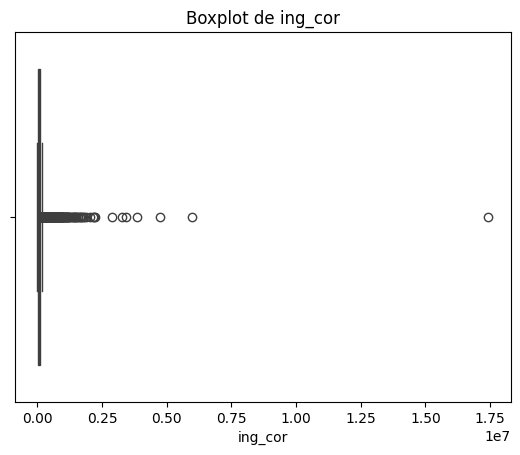

In [99]:
#Demostracion de sesgo en la variable "ing_cor"
sns.boxplot(x=df_model["ing_cor"])
plt.title("Boxplot de ing_cor")
plt.show()

## 1.4 Limpieza de datos

In [100]:
#Transformación logarítmica para outliers
for col in columns_ingr_jefe:
    df_model[col] = np.log1p(df_model[col])

/tmp/ipykernel_20359/313872309.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = np.log1p(df_model[col])


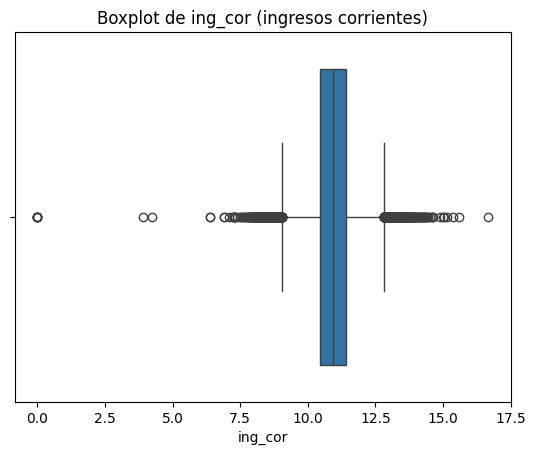

In [101]:
sns.boxplot(x=df_model["ing_cor"])
plt.title("Boxplot de ing_cor (ingresos corrientes)")
plt.show()

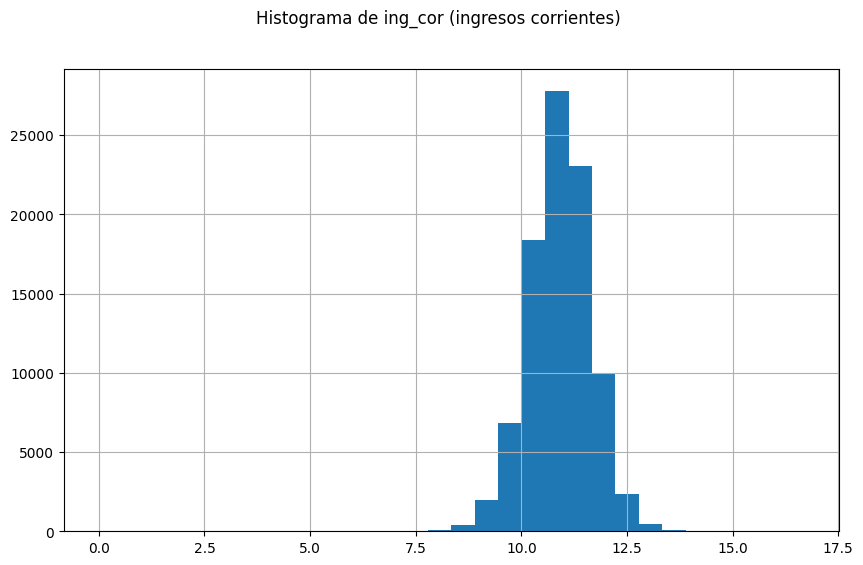

In [102]:
df_model['ing_cor'].hist(bins=30, figsize=(10,6))
plt.suptitle("Histograma de ing_cor (ingresos corrientes)")
plt.show()

Durante la etapa de preprocesamiento, se aplicaron técnicas orientadas a mejorar la calidad y distribución de las variables, particularmente aquellas de tipo económico, caracterizadas por alta dispersión y presencia de valores extremos.

Con el objetivo de mitigar el efecto de outliers y reducir la asimetría positiva en variables como ingresos y gastos, se implementó una transformación logarítmica utilizando la función
log
⁡
(
1
+
𝑥
)
log(1+x). Esta transformación permitió comprimir la escala de los valores elevados sin perder la información relativa entre observaciones.

La aplicación se realizó de manera iterativa sobre el conjunto de variables económicas (columns_ing_jefe), asegurando una transformación homogénea en todas ellas. Este procedimiento es común en análisis socioeconómicos, donde las distribuciones suelen ser altamente sesgadas.

In [103]:
df_model.describe()

,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas
count,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000
mean,2.121787,1.323386,51.537281,5.884132,0.613331,10.913652,10.407163,9.176288,6.339425,2.638833,0.210753
std,0.643906,0.467771,15.994928,2.575050,0.915634,0.738044,0.779184,3.607065,4.319474,4.190399,1.261686
min,1.000000,1.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,39.000000,4.000000,0.000000,10.449348,9.976986,9.587676,0.000000,0.000000,0.000000
50%,2.000000,1.000000,51.000000,6.000000,0.000000,10.927146,10.439499,10.502650,8.409263,0.000000,0.000000
75%,2.000000,2.000000,63.000000,8.000000,1.000000,11.394612,10.878955,11.082306,9.711844,7.297514,0.000000
max,5.000000,2.000000,106.000000,11.000000,9.000000,16.673817,14.307723,14.669001,14.978933,14.598514,12.084188


Se generó una nueva variable binaria denominada con_negocio, la cual indica la presencia de ingresos por actividad empresarial. Esta se construyó a partir de la variable original negocio, asignando el valor de 1 cuando el ingreso es mayor a cero y 0 en caso contrario.

Esta transformación permite simplificar la variable continua en una representación categórica, facilitando su uso en modelos de clasificación y análisis interpretativo.

In [104]:
df_model["con_negocio"] = (df_model["negocio"] > 0).astype(int)
df_model.head()

/tmp/ipykernel_20359/3905636569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["con_negocio"] = (df_model["negocio"] > 0).astype(int)


,clase_hog,sexo_jefe,edad_jefe,educa_jefe,menores,ing_cor,gasto_mon,ingtrab,transfer,negocio,becas,con_negocio
0,2,1,32,6,2,11.836699,10.768057,11.779275,8.950958,0.0,0.0,0
1,2,1,48,9,0,11.678567,10.565756,11.550517,7.852602,0.0,0.0,0
2,2,2,60,6,0,10.755076,10.261241,10.727260,7.159844,0.0,0.0,0
3,2,1,43,8,0,11.612147,10.680765,11.484227,5.281375,0.0,0.0,0
4,2,2,29,8,2,11.507864,11.794741,11.447733,0.000000,0.0,0.0,0


## 1.5 Partituracion de datos para entrenamiento y prueba

¿Se definió la variable objetivo (y) a partir de sexo_jefe, ajustando su codificación mediante la resta de 1, con el fin de transformarla a un formato binario estándar (0 y 1), requerido por modelos de clasificación como XGBoost.

In [105]:
y = df_model["sexo_jefe"] - 1
X = df_model.drop("sexo_jefe", axis=1)

El análisis de frecuencias de la variable sexo_jefe revela una distribución desbalanceada, donde la categoría 1 presenta una mayor proporción (61,852 casos) en comparación con la categoría 2 (29,562 casos).

Este hallazgo indica que la mayoría de los hogares están encabezados por un solo grupo (hombres), lo cual introduce un desbalance de clases en la variable objetivo.

Dicho desbalance es relevante para el modelado, ya que puede sesgar el desempeño del modelo hacia la clase mayoritaria, por lo que se recomienda considerar técnicas como ponderación de clases o métricas robustas (F1-score, recall) en la evaluación

In [106]:
print('Mucho mas hombres que mujeres')
df_model["sexo_jefe"].value_counts()

Mucho mas hombres que mujeres


,count
sexo_jefe,
1,61852
2,29562


In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 1.6 Matriz de corelacion de variables

In [108]:
corr = df_model.corr()
print(corr)

             clase_hog  sexo_jefe  edad_jefe  educa_jefe   menores   ing_cor  \
clase_hog     1.000000   0.016225   0.021987   -0.065560  0.277552  0.251055   
sexo_jefe     0.016225   1.000000   0.084600   -0.050710 -0.057627 -0.066794   
edad_jefe     0.021987   0.084600   1.000000   -0.403845 -0.364719 -0.059202   
educa_jefe   -0.065560  -0.050710  -0.403845    1.000000  0.032052  0.406754   
menores       0.277552  -0.057627  -0.364719    0.032052  1.000000  0.023474   
ing_cor       0.251055  -0.066794  -0.059202    0.406754  0.023474  1.000000   
gasto_mon     0.237393  -0.088498  -0.178048    0.432768  0.093857  0.684908   
ingtrab       0.262210  -0.137630  -0.374607    0.193443  0.169436  0.364826   
transfer      0.082107   0.159602   0.372411   -0.170220 -0.040525 -0.027127   
negocio       0.096655  -0.090198   0.038295   -0.115317  0.047906 -0.058436   
becas         0.055537  -0.007437  -0.058961    0.035051  0.109220  0.039298   
con_negocio   0.096525  -0.084352   0.05

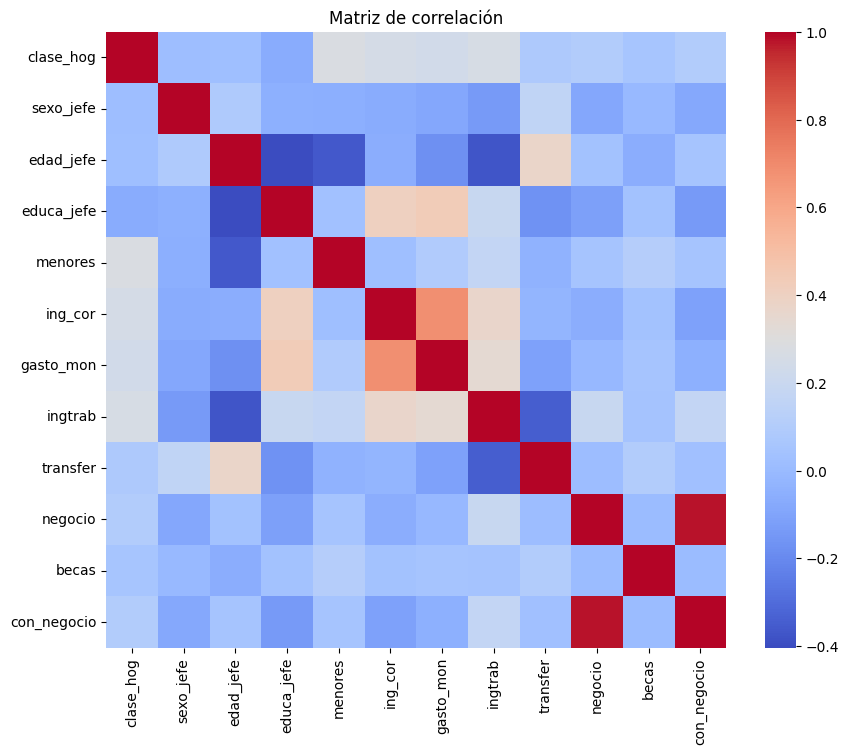

In [109]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

Con el objetivo de abordar el desbalance de clases en la variable objetivo (sexo_jefe), se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento.

Este método genera nuevas muestras sintéticas de la clase minoritaria a partir de interpolaciones entre observaciones existentes, permitiendo equilibrar la distribución sin duplicar datos.

Como resultado, ambas clases quedaron perfectamente balanceadas (49,481 observaciones cada una), lo que contribuye a:

Reducir el sesgo del modelo hacia la clase mayoritaria
Mejorar la capacidad de generalización
Obtener métricas de evaluación más representativas

Este paso es fundamental para garantizar un entrenamiento más justo y robusto en modelos de clasificación.

In [110]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [111]:
pd.Series(y_train_res).value_counts()

,count
sexo_jefe,
0,49481
1,49481


## 1.7 Evaluación y comparación de modelos de clasificación

Se evaluaron distintos modelos de aprendizaje automático con el objetivo de predecir el sexo del jefe del hogar a partir de variables sociodemográficas y económicas. Entre los modelos analizados se incluyen Random Forest, Regresión Logística, Redes Neuronales (MLP) y XGBoost.

En términos generales, los resultados muestran diferencias significativas en el desempeño de los modelos. La Regresión Logística presentó el menor rendimiento, con una accuracy de 0.58 y un F1-score de 0.48 en la clase minoritaria, lo que sugiere que el problema no puede ser adecuadamente modelado mediante relaciones lineales.

Por su parte, Random Forest y MLP mostraron mejoras moderadas, alcanzando accuracy cercanas a 0.66–0.67 y F1-scores en la clase minoritaria de aproximadamente 0.50–0.54. Sin embargo, estos modelos aún presentan limitaciones en la identificación de la clase minoritaria, evidenciando dificultades para capturar patrones complejos en los datos.

El modelo XGBoost, en su configuración inicial, obtuvo un desempeño comparable, con una accuracy de 0.67 y un F1-score de 0.54 en la clase minoritaria. No obstante, tras la aplicación de técnicas de optimización —incluyendo ingeniería de características, control de outliers, balanceo de clases mediante SMOTE y ajuste de hiperparámetros—, se logró una mejora significativa en su rendimiento.

El modelo XGBoost optimizado alcanzó una accuracy de 0.73, con un F1-score de 0.56 en la clase minoritaria, además de una mejora notable en precision (0.60) y recall (0.53) para dicha clase. Este comportamiento indica una mayor capacidad del modelo para identificar correctamente instancias de la clase menos representada, manteniendo al mismo tiempo un alto desempeño general.

En comparación con los demás modelos, XGBoost demostró un comportamiento superior debido a su capacidad para capturar relaciones no lineales, manejar interacciones complejas entre variables y adaptarse a distribuciones sesgadas. Estas características lo convierten en una opción más robusta para problemas con estructuras de datos heterogéneas y desbalanceadas.



In [ ]:
model_Random_forest = RandomForestClassifier(random_state=42)

model_Random_forest.fit(X_train_res, y_train_res)
y_pred = model_Random_forest.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6712793305256249
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     12371
           1       0.49      0.51      0.50      5912

    accuracy                           0.67     18283
   macro avg       0.63      0.63      0.63     18283
weighted avg       0.68      0.67      0.67     18283



### 1.7.1 Optimizacion XGBClassifier

In [114]:
#creamos copia principal
df_model_op = df_caracteristicas_hogar.copy()
df_model_op.head()

,folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
0,100001901,1,1001,1,3,1,1,207,2,1,...,0.00,0.00,0.0,21365.21,0.00,0.00,8217.39,0.0,0.00,22403.7
1,100001902,1,1001,1,3,1,1,207,2,1,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,22403.7
2,100001904,1,1001,1,3,1,1,207,2,2,...,0.00,0.00,0.0,4695.65,0.00,0.00,0.00,0.0,0.00,22403.7
3,100001905,1,1001,1,3,1,1,207,2,1,...,366.84,366.84,0.0,5869.56,0.00,7336.95,2934.78,0.0,6260.86,22403.7
4,100002501,1,1001,1,2,2,2,196,2,2,...,0.00,0.00,0.0,0.00,2934.78,0.00,0.00,0.0,7113.91,22403.7


### 1.7.2 Creacion de nuevas variables
Con el propósito de mejorar la capacidad predictiva del modelo y capturar relaciones más complejas entre las variables originales, se llevó a cabo un proceso de ingeniería de características (feature engineering). Este proceso consistió en la construcción de variables derivadas que integran información económica y demográfica a nivel del hogar, permitiendo representar de manera más precisa las condiciones socioeconómicas.

En primer lugar, se generó la variable ratio_gasto_ingreso, la cual expresa la proporción del ingreso destinada al gasto. Este indicador permite evaluar el nivel de presión económica en los hogares, donde valores elevados pueden reflejar una menor capacidad de ahorro o mayor vulnerabilidad financiera.

Asimismo, se construyó la variable ingreso_per_capita, definida como el ingreso total dividido entre el número de integrantes del hogar. Este indicador constituye una medida más precisa del bienestar económico individual, al ajustar el ingreso por el tamaño del hogar.

Para capturar la carga económica dentro del hogar, se definió la variable dependencia, que representa la relación entre el número de menores y el número de personas ocupadas. Este indicador permite evaluar el grado de presión que enfrentan los miembros económicamente activos al sostener a dependientes.

De manera complementaria, se incorporó la variable ratio_ocupados, que mide la proporción de integrantes del hogar que participan en actividades productivas. Este indicador refleja la capacidad del hogar para generar ingresos y su nivel de inserción en el mercado laboral.

En cuanto a la diversificación de ingresos, se generó la variable div_ingresos, la cual cuantifica la proporción de integrantes que perciben ingresos. Esta variable permite identificar hogares con múltiples fuentes de ingreso, lo cual puede asociarse con mayor estabilidad económica.

Por otro lado, la variable ratio_transfer mide la proporción del ingreso total que proviene de transferencias, tales como apoyos gubernamentales o remesas. Este indicador resulta relevante para identificar niveles de dependencia de fuentes de ingreso no laborales.

Adicionalmente, se definió la variable binaria con_negocio, la cual indica la presencia de ingresos provenientes de actividades independientes. Esta variable permite capturar la participación del hogar en actividades económicas no asalariadas.

La variable ratio_ingtrab fue incorporada con el objetivo de medir la proporción del ingreso total que proviene del trabajo, diferenciando así entre ingresos laborales y no laborales.

Para representar la composición demográfica del hogar, se construyó la variable carga_familiar, que considera la proporción de personas dependientes (menores y adultos mayores) respecto al total de integrantes. Este indicador permite evaluar la presión demográfica sobre los recursos económicos del hogar.

Finalmente, se incluyó la variable gasto_per_capita, que mide el gasto promedio por persona, proporcionando una aproximación al nivel de consumo individual dentro del hogar.

En conjunto, estas variables derivadas permiten transformar la información original en indicadores más interpretables y representativos de la realidad socioeconómica, lo cual contribuye a mejorar la capacidad del modelo para identificar patrones complejos y relaciones no lineales en los datos.

In [129]:
# Evitar divisiones entre 0
epsilon = 1

# Ratio gasto / ingreso
df_model_op["ratio_gasto_ingreso"] = df_model_op["gasto_mon"] / (df_model_op["ing_cor"] + epsilon)

# Ingreso per cápita
df_model_op["ingreso_per_capita"] = df_model_op["ing_cor"] / (df_model_op["tot_integ"] + epsilon)

# Dependencia económica (personas dependientes vs ocupados)
df_model_op["dependencia"] = df_model_op["menores"] / (df_model_op["ocupados"] + epsilon)

#Intensidad laboral (ocupados vs total)
df_model_op["ratio_ocupados"] = df_model_op["ocupados"] / (df_model_op["tot_integ"] + epsilon)

# Diversificación de ingresos
df_model_op["div_ingresos"] = df_model_op["percep_ing"] / (df_model_op["tot_integ"] + epsilon)

#Peso de transferencias
df_model_op["ratio_transfer"] = df_model_op["transfer"] / (df_model_op["ing_cor"] + epsilon)

#Indicador binario de negocio
df_model_op["con_negocio"] = (df_model_op["negocio"] > 0).astype(int)

#Ratio ingreso laboral / ingreso total
df_model_op["ratio_ingtrab"] = df_model_op["ingtrab"] / (df_model_op["ing_cor"] + epsilon)

#Carga familiar (mayores + menores)
df_model_op["carga_familiar"] = (df_model_op["menores"] + df_model_op["p65mas"]) / (df_model_op["tot_integ"] + epsilon)

# Gasto per cápita
df_model_op["gasto_per_capita"] = df_model_op["gasto_mon"] / (df_model_op["tot_integ"] + epsilon)

### 1.7.3 Instanciamiento

In [138]:
caract_op = [
    "ing_cor",
    "ingtrab",
    "gasto_mon",
    "transfer",
    "edad_jefe",
    "educa_jefe",
    "sexo_jefe",
    "tot_integ",
    "menores",
    "ocupados",
    "percep_ing",
    "p65mas",
    "negocio",
    "con_negocio",
    "ratio_gasto_ingreso",
    "ingreso_per_capita",
    "dependencia",
    "ratio_ocupados",
    "div_ingresos",
    "ratio_transfer",
    "ratio_ingtrab",
    "carga_familiar",
    "gasto_per_capita"
]

### 1.7.4 Creacion de dataset


In [139]:
df_final = df_model_op[caract_op].copy()

df_final.head()

,ing_cor,ingtrab,gasto_mon,transfer,edad_jefe,educa_jefe,sexo_jefe,tot_integ,menores,ocupados,...,con_negocio,ratio_gasto_ingreso,ingreso_per_capita,dependencia,ratio_ocupados,div_ingresos,ratio_transfer,ratio_ingtrab,carga_familiar,gasto_per_capita
0,138232.38,130518.10,47478.66,7714.28,32,6,1,4,2,2,...,0,0.343467,27646.476000,0.666667,0.400000,0.400000,0.055806,0.944187,0.4,9495.732000
1,118014.04,103829.72,38782.74,2571.42,48,9,1,4,0,2,...,0,0.328625,23602.808000,0.000000,0.400000,0.400000,0.021789,0.879801,0.0,7756.548000
2,46866.32,45580.61,28601.26,1285.71,60,6,2,2,0,2,...,0,0.610260,15622.106667,0.000000,0.666667,0.666667,0.027433,0.972546,0.0,9533.753333
3,110430.10,97169.95,43509.83,195.64,43,8,1,4,0,3,...,0,0.394000,22086.020000,0.000000,0.600000,0.600000,0.001772,0.879915,0.0,8701.966000
4,99494.12,93687.67,132552.40,0.00,29,8,2,4,2,2,...,0,1.332250,19898.824000,0.666667,0.400000,0.400000,0.000000,0.941631,0.4,26510.480000


### 1.7.5 Uso de transformaciones logarítmicas para el tratamiento de valores atípicos

In [152]:
cols_log = [
    "ing_cor", "ingtrab", "gasto_mon", "transfer",
    "ingreso_per_capita", "gasto_per_capita",
    "ratio_gasto_ingreso"
]

for col in cols_log:
    df_final[col] = np.log1p(df_final[col])

In [153]:
for col in df_final.columns:
    p99 = df_final[col].quantile(0.99)
    df_final[col] = np.clip(df_final[col], None, p99)

In [154]:
df_final.describe()

,ing_cor,ingtrab,gasto_mon,transfer,edad_jefe,educa_jefe,sexo_jefe,tot_integ,menores,ocupados,...,con_negocio,ratio_gasto_ingreso,ingreso_per_capita,dependencia,ratio_ocupados,div_ingresos,ratio_transfer,ratio_ingtrab,carga_familiar,gasto_per_capita
count,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,...,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000,91414.000000
mean,1.245523,1.080242,1.232414,0.833716,51.500438,5.884132,1.323386,3.363774,0.600061,1.627628,...,0.292570,0.331681,1.208790,0.242723,0.371832,0.511121,0.223528,0.622747,0.209800,1.193464
std,0.020427,0.407941,0.033778,0.548142,15.903405,2.575050,0.467771,1.710455,0.867165,1.059994,...,0.454945,0.093306,0.022846,0.389526,0.205819,0.173236,0.284404,0.332253,0.203719,0.034672
min,0.000000,0.000000,0.000000,0.000000,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.234870,1.211849,1.222540,0.000000,39.000000,4.000000,1.000000,2.000000,0.000000,1.000000,...,0.000000,0.270338,1.196577,0.000000,0.250000,0.400000,0.000000,0.409467,0.000000,1.181365
50%,1.246692,1.236220,1.234620,1.176096,51.000000,6.000000,1.000000,3.000000,0.000000,1.000000,...,0.000000,0.330400,1.209781,0.000000,0.375000,0.500000,0.082900,0.752712,0.200000,1.194685
75%,1.257683,1.250401,1.245528,1.215313,63.000000,8.000000,2.000000,4.000000,1.000000,2.000000,...,1.000000,0.390555,1.222353,0.400000,0.500000,0.666667,0.367204,0.884233,0.333333,1.207900
max,1.284612,1.278128,1.274045,1.263264,88.000000,11.000000,2.000000,9.000000,3.000000,5.000000,...,1.000000,0.586677,1.255566,2.000000,0.800000,0.833333,0.953351,0.999990,0.666667,1.244713


In [155]:
X = df_final.drop("sexo_jefe", axis=1)
y = df_final["sexo_jefe"] - 1 #cambia: 0 -> Hombres, 1 -> mujeres

### 1.7.6 Partitura de dataset

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [157]:
smote = SMOTE(random_state=42)

X_train_ris, y_train_ris = smote.fit_resample(X_train, y_train)

In [147]:
print(pd.Series(y_train_ris).value_counts())

sexo_jefe
0    49481
1    49481
Name: count, dtype: int64


### 1.7.7 Modelo optimizado

In [158]:
model_XGB = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42
)

model_XGB.fit(X_train_ris, y_train_ris)

y_pred = model_XGB.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7340699010009298
              precision    recall  f1-score   support

           0       0.79      0.83      0.81     12371
           1       0.60      0.53      0.56      5912

    accuracy                           0.73     18283
   macro avg       0.69      0.68      0.69     18283
weighted avg       0.73      0.73      0.73     18283



In [ ]:
model_logistic = LogisticRegression(max_iter=1000)

model_logistic.fit(X_train_res, y_train_res)
y_pred = model_logistic.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5826724279385221
              precision    recall  f1-score   support

           0       0.75      0.57      0.65     12371
           1       0.40      0.60      0.48      5912

    accuracy                           0.58     18283
   macro avg       0.58      0.59      0.57     18283
weighted avg       0.64      0.58      0.60     18283



In [ ]:
model_red_MLP = MLPClassifier(max_iter=500)

model_red_MLP.fit(X_train_res, y_train_res)
y_pred = model_red_MLP.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6624733358857956
              precision    recall  f1-score   support

           0       0.79      0.69      0.73     12371
           1       0.48      0.61      0.54      5912

    accuracy                           0.66     18283
   macro avg       0.63      0.65      0.64     18283
weighted avg       0.69      0.66      0.67     18283



## 1.8 Interpretacion del modelo

### 1.8.1 Importancia de variables en Random Forest

Con el objetivo de identificar los factores más relevantes en la predicción del sexo del jefe del hogar, se analizó la importancia de las variables utilizando el modelo XGBoost. Esta métrica se basa en la contribución de cada variable a la reducción del error durante la construcción de los árboles de decisión.

Los resultados indican que la variable p65mas (número de integrantes de 65 años o más) presenta la mayor importancia (0.2279), destacándose significativamente por encima del resto. Este hallazgo sugiere que la presencia de adultos mayores en el hogar es un factor determinante en la diferenciación entre clases.

En segundo lugar, se encuentran variables relacionadas con la estructura del hogar, como tot_integ (total de integrantes) y menores, lo que evidencia que la composición demográfica juega un papel clave en el comportamiento del modelo.

Asimismo, variables derivadas como ratio_transfer, div_ingresos, ratio_ocupados y dependencia presentan una relevancia considerable. Estas variables capturan relaciones más complejas entre ingresos, ocupación y composición familiar, lo que permite al modelo identificar patrones no lineales en los datos.

La variable con_negocio también muestra una contribución importante, indicando que la presencia de actividades económicas independientes influye en la diferenciación entre grupos.

En conjunto, los resultados revelan que las variables más influyentes no corresponden directamente a los niveles absolutos de ingreso, sino a la estructura del hogar y la dinámica económica interna, incluyendo factores como la dependencia, la diversificación de ingresos y la participación laboral.

In [161]:
importancias = pd.Series(
    model_XGB.feature_importances_,
    index=X_train.columns
)

print(importancias.sort_values(ascending=False).head(10))

p65mas            0.227970
tot_integ         0.075985
menores           0.073858
ratio_transfer    0.065091
con_negocio       0.062901
div_ingresos      0.061394
ocupados          0.058166
carga_familiar    0.053031
ratio_ocupados    0.046814
dependencia       0.045222
dtype: float32


### 1.8.2 Interpretabilidad del modelo mediante SHAP

La gráfica SHAP permite identificar no solo las variables más influyentes, sino también la dirección de su impacto sobre la clasificación. Dado que los valores positivos del modelo (lado derecho) corresponden a mujeres y los negativos (lado izquierdo) a hombres, es posible observar patrones diferenciados entre ambos grupos.

En primer lugar, variables como dependencia y carga_familiar presentan valores altos asociados consistentemente con la región positiva, lo que indica que los hogares encabezados por mujeres enfrentan una mayor carga de personas dependientes. Este resultado sugiere que las mujeres asumen en mayor medida responsabilidades de cuidado, lo cual limita su disponibilidad para participar plenamente en el mercado laboral.

Asimismo, la variable ratio_transfer muestra que valores elevados se concentran en la región correspondiente a mujeres, evidenciando una mayor dependencia relativa de transferencias. Esto indica que una proporción significativa de los ingresos en estos hogares proviene de fuentes no laborales, lo cual es consistente con una menor inserción en empleos formales o estables.

En contraste, variables como ocupados, ingtrab y ratio_ingtrab presentan valores altos asociados con la región negativa del modelo, correspondiente a hombres. Esto evidencia que los hogares encabezados por hombres cuentan con mayor participación laboral y una mayor proporción de ingresos provenientes del trabajo, lo que refleja un mejor acceso a oportunidades laborales.

Adicionalmente, variables como percep_ing y tot_integ también se inclinan hacia la región de hombres, indicando una mayor cantidad de perceptores de ingreso y una estructura económica más activa dentro del hogar.

En conjunto, estos patrones muestran una clara diferenciación:

Las mujeres se asocian con mayor carga de dependencia y mayor uso de ingresos no laborales.
Los hombres se asocian con mayor participación laboral y mayor generación de ingresos por trabajo.

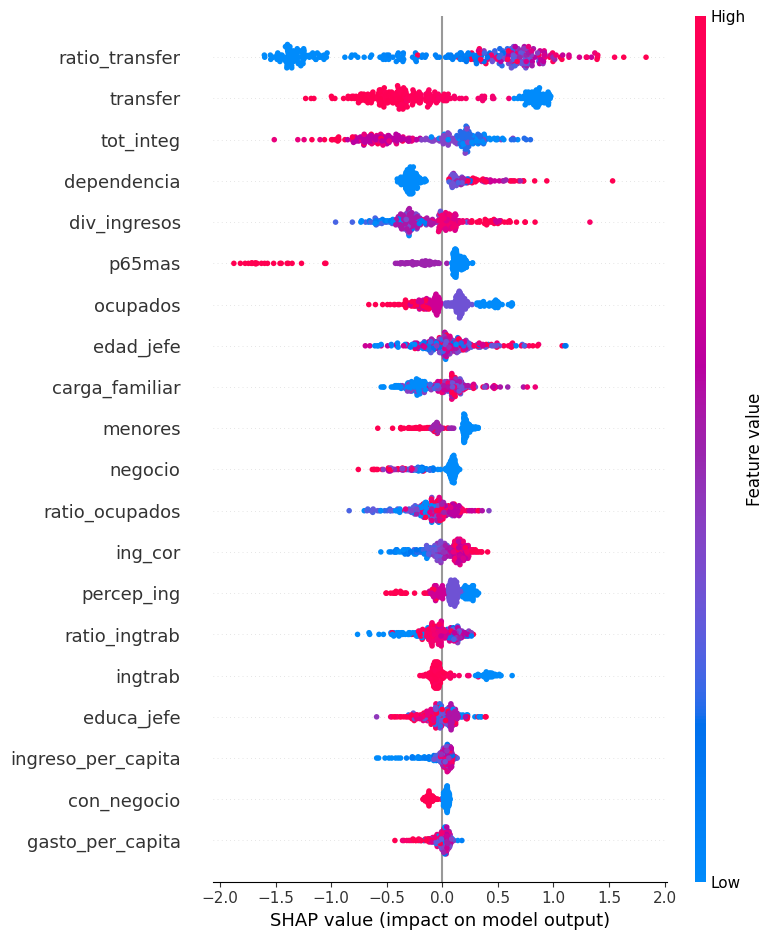

In [160]:
#Derecha = Mujeres (1)
#Izquierda = Hombres (0)
X_sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(model_XGB)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

## 1.9 Análisis comparativo de ingresos por sexo del jefe del hogar (plus)

Con el objetivo de explorar posibles diferencias económicas entre grupos, se realizó un análisis visual mediante diagramas de caja (boxplot) de la variable ing_cor (ingreso corriente) en función de sexo_jefe.

Los resultados muestran que ambas distribuciones presentan una forma similar, con medianas cercanas y rangos intercuartílicos comparables, lo que sugiere que, a nivel general, los ingresos no difieren drásticamente entre ambos grupos. Sin embargo, se observan diferencias sutiles en la dispersión y en la presencia de valores extremos.

En particular, uno de los grupos presenta una ligera mayor concentración de valores altos y una mayor variabilidad, lo que podría indicar una mayor heterogeneidad en los niveles de ingreso. Asimismo, la presencia de múltiples outliers en ambos casos refleja la naturaleza altamente sesgada de las variables económicas.

Aunque las diferencias visuales no son extremadamente marcadas, este análisis sugiere que sí existen variaciones en la distribución de ingresos entre los grupos, las cuales podrían estar siendo capturadas por los modelos de aprendizaje automático.

Estos hallazgos, en conjunto con los resultados de los modelos predictivos y el análisis de importancia de variables, refuerzan la idea de que las variables económicas contienen información relevante para diferenciar entre grupos, lo cual es consistente con la posible existencia de una brecha económica.

No obstante, se recomienda complementar este análisis con pruebas estadísticas formales para determinar si las diferencias observadas son estadísticamente significativas.

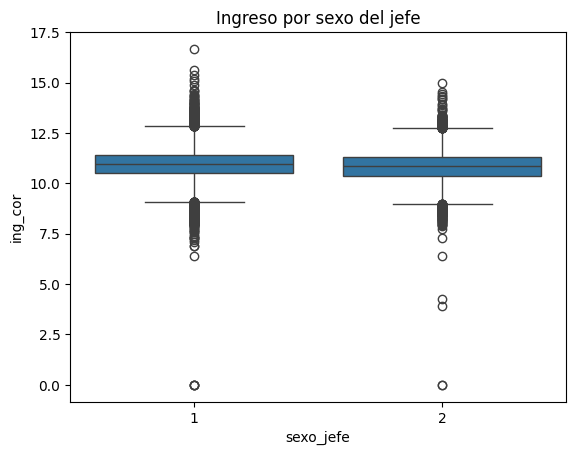

In [ ]:
sns.boxplot(x="sexo_jefe", y="ing_cor", data=df_model)

plt.title("Ingreso por sexo del jefe")
plt.show()

# Fuentes
[Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) ](https://www.inegi.org.mx/programas/enigh/nc/2024/#datos_abiertos)